# Jnaneswara_EDA_Checklist_Assignment




In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


# Task 1: Inspect and Handle missing values


In [3]:
df.shape

(200, 6)

row = 200
coloumns = 6

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       200 non-null    int64  
 1   city           200 non-null    object 
 2   category       200 non-null    object 
 3   order_value    186 non-null    float64
 4   delivery_days  190 non-null    float64
 5   rating         168 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 9.5+ KB


In [8]:
df.isnull().sum()

,0
order_id,0
city,0
category,0
order_value,14
delivery_days,10
rating,32


In [17]:
total_rows = 200
total_coloumns = 6
percentage = (df.isnull().sum()/total_rows)*100
missing_percentage = percentage.round(2)
print(f"Percentage of missing values for each coloumn: \n{missing_percentage})")

Percentage of missing values for each coloumn: 
order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64)


# Task 2: Summarize and Visualize

In [18]:
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


1. Average order value = 3707, average delivery days = 7.8 (approx. 8 days) to deliver
2. min order value = 204 and min delivery days = 1 day
3. 75% of order value was 3987.5 and 75% of orders taken 12 days of delivery time
4. order value has the highest mean when compared to orderid, delivery days


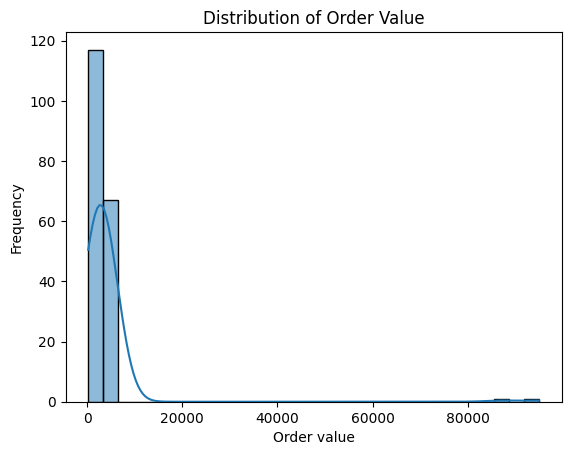

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["order_value"], bins=30, kde=True)

plt.xlabel("Order value")
plt.ylabel("Frequency")
plt.title("Distribution of Order Value")
plt.show()

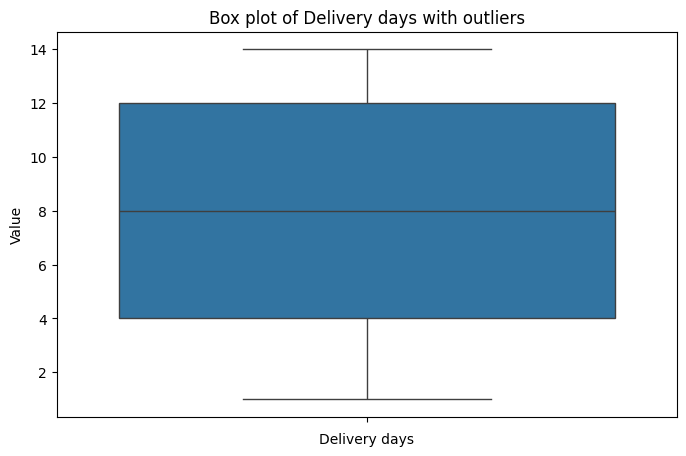

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(df["delivery_days"], showfliers = True)

plt.title("Box plot of Delivery days with outliers")
plt.xlabel("Delivery days")
plt.ylabel("Value")
plt.show()

# Task 3: Correlation Analysis

In [33]:
df.corr(numeric_only = True)

,order_id,order_value,delivery_days
order_id,1.000000,-0.095503,0.004858
order_value,-0.095503,1.000000,0.141660
delivery_days,0.004858,0.141660,1.000000


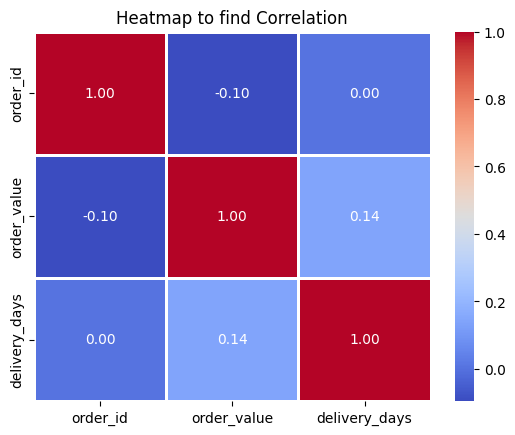

In [35]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot = True, cmap = 'coolwarm', linewidths=1, fmt= '.2f')
plt.title("Heatmap to find Correlation")
plt.show()

There is a positive relationship between order_value and delivery_days, indicating that orders with higher values tend to have slightly longer delivery times.